In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, roc_auc_score)


In [3]:
#create dataset 

X , y = make_classification(
    n_samples= 500,
    n_features = 7,
    n_informative = 4,
    n_redundant = 1 ,
    n_classes = 2,
    weights = [0.6 , 0.4],
    random_state = 42

)

df = pd.DataFrame(X , columns=[f'feature_{i+1}' for i in range(X.shape[1])])
df['target'] = y

In [ ]:
df.head()
print(df.shape) 

(500, 8)


In [ ]:
df.isnull().sum()

feature_1    0
feature_2    0
feature_3    0
feature_4    0
feature_5    0
feature_6    0
feature_7    0
target       0
dtype: int64

In [9]:
df['target'].value_counts()

target
0    302
1    198
Name: count, dtype: int64

Text(0.5, 1.0, 'class Balance')

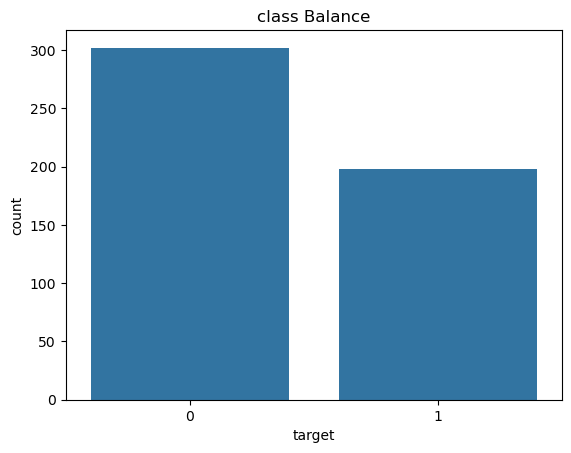

In [10]:
sns.countplot(x = 'target' , data = df)
plt.title('class Balance')

Text(0.5, 1.0, 'Correlation Heatmap')

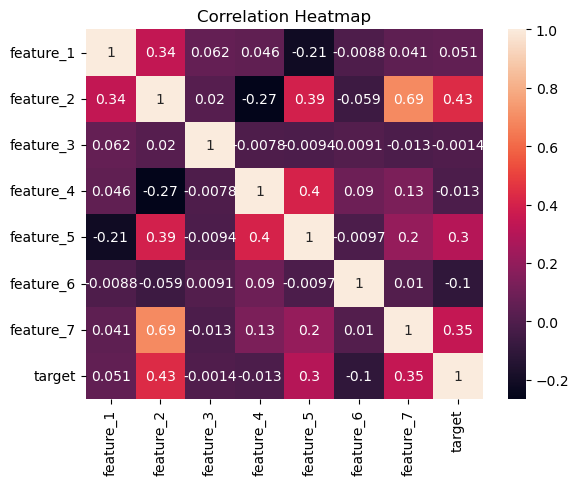

In [13]:
sns.heatmap(df.corr(), annot=True)
plt.title('Correlation Heatmap')

In [16]:
X = df.drop('target' , axis = 1)
y = df['target']

X , y

(     feature_1  feature_2  feature_3  feature_4  feature_5  feature_6  \
 0     1.691954   2.947127  -2.488562  -4.181512  -1.940913   0.330291   
 1     1.053366   0.610627   1.373808   1.427951  -1.535227  -1.805557   
 2     1.058554   1.848908   2.267180   1.726136   0.770036   2.479389   
 3     0.874749  -1.750079   0.585491   0.930555  -0.428907  -1.256761   
 4     1.781367  -0.259940   0.357838   0.440250  -0.466457   1.516813   
 ..         ...        ...        ...        ...        ...        ...   
 495   0.043071  -1.150384   0.135754  -1.897326  -2.790474  -0.763149   
 496  -0.810253   2.548267   1.076923   0.567215   2.106501   0.066815   
 497  -1.448504  -1.913454   1.195336  -0.857242  -0.820288  -0.859088   
 498   0.664429  -2.354093  -1.268014   1.306103  -1.476548  -0.179150   
 499   0.980579  -2.006748  -0.274899   0.510490   0.787480  -0.345393   
 
      feature_7  
 0     0.071408  
 1     2.862033  
 2     2.227351  
 3    -1.354450  
 4    -0.749172  
 .

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [22]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [24]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", round(grid.best_score_, 4))

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Best CV Score: 0.8648


In [25]:
model = grid.best_estimator_

In [26]:
y_pred = model.predict(X_test_scaled)

In [28]:
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:", round(recall_score(y_test, y_pred), 4))
print("F1 Score:", round(f1_score(y_test, y_pred), 4))


print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.86
Precision: 0.9062
Recall: 0.725
F1 Score: 0.8056
Confusion Matrix:
 [[57  3]
 [11 29]]
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.95      0.89        60
           1       0.91      0.72      0.81        40

    accuracy                           0.86       100
   macro avg       0.87      0.84      0.85       100
weighted avg       0.87      0.86      0.86       100

